### Goal of this Notebook 

Visualize date to access and validate the benchmark for matrix multiplication

In [2]:
pip install matplotlib pandas plotly networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 20.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np 
import json 
import matplotlib.pyplot as plt
from pathlib import Path


In [25]:
# Load JSON data from a file
with open(Path('results/numpy_reference.json'), 'r') as file:
    python_data = json.load(file)
    
with open(Path('results/result_O0.json'), 'r') as file:
    c_O0data = json.load(file)
    
with open(Path('results/result_O2.json'), 'r') as file:
    c_O2data = json.load(file)
    
with open(Path('results/result_O3.json'), 'r') as file:
    c_O3data = json.load(file)
    
    
t_numpyref = []
t_O0c = []
t_O2c = []
t_O3c = []
matrix_size = []
number_ops = []

    
for i in range(len(python_data)):
    t_numpyref.append(python_data[i]["inference time (in sec)"])
    t_O0c.append(c_O0data[i]["inference time (in sec)"])
    t_O2c.append(c_O2data[i]["inference time (in sec)"])
    t_O3c.append(c_O3data[i]["inference time (in sec)"])
    matrix_size.append(python_data[i]["final_matrix size"])
    number_ops.append(c_O0data[i]["nb_operations"])
    

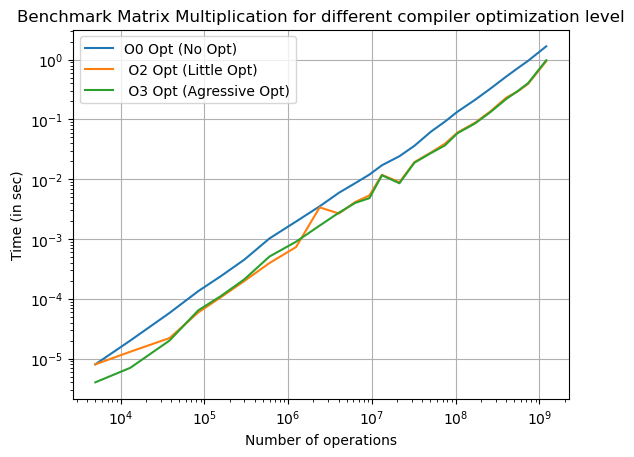

In [26]:
# Let's visualize the different levels of optimization

# plotting the line 1 points 
plt.plot(number_ops, t_O0c, label = "O0 Opt (No Opt)")
plt.plot(number_ops, t_O2c, label = " O2 Opt (Little Opt)")
plt.plot(number_ops, t_O3c, label = " O3 Opt (Agressive Opt)")

plt.xscale("log")
plt.yscale("log")
plt.xlabel('Number of operations')
plt.ylabel('Time (in sec)')
plt.title('Benchmark Matrix Multiplication for different compiler optimization level')
plt.legend()
plt.grid(True)
plt.show()

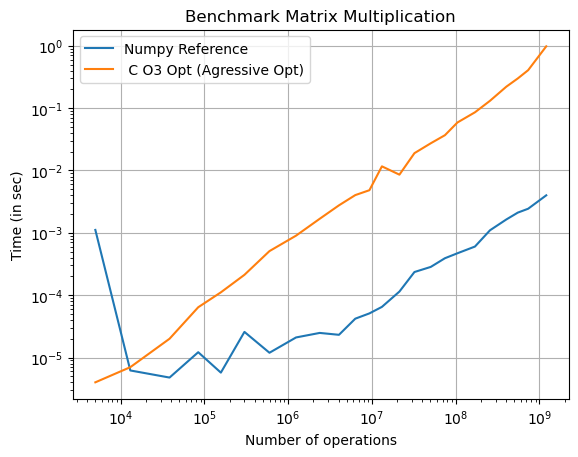

In [27]:
# Let's visualize the graph 

# plotting the line 1 points 
plt.plot(number_ops, t_numpyref, label = "Numpy Reference")
plt.plot(number_ops, t_O3c, label = " C O3 Opt (Agressive Opt)")

plt.xscale("log")
plt.yscale("log")
plt.xlabel('Number of operations')
plt.ylabel('Time (in sec)')
plt.title('Benchmark Matrix Multiplication')
plt.legend()
plt.grid(True)
plt.show()
